#  Estrategia Cuantitativa: Donchian(20) + CCI(14) + Filtro SMA(200)

## Selección de Features, Justificación de Indicadores y Backtesting sobre US500

**Máster en Formación Permanente en Inteligencia Artificial para el Sector Financiero**
Universidad Internacional de Valencia

---

**Autor de la estrategia:** Félix López
**Activo analizado:** US500 (CFD sobre el índice S&P 500), velas de 15 minutos

REGLA DE ENTRADA EN LARGO
════════════════════════════════════════════════════════════
  1) Rompimiento (breakout) del canal Donchian de 20 periodos AL ALZA
  2) Gatillo: el CCI(14) cruza al alza el nivel +200
  3) Filtro de contexto: el precio de cierre está POR ENCIMA de la SMA(200)

REGLA DE ENTRADA EN CORTO (simétrica)
════════════════════════════════════════════════════════════
  1) Rompimiento del canal Donchian de 20 periodos A LA BAJA
  2) Gatillo: el CCI(14) cruza a la baja el nivel -200
  3) Filtro de contexto: el precio de cierre está POR DEBAJO de la SMA(200)
```

---
Configuración del Entorno

Se importan las librerías necesarias para manipulación de datos, cálculo de indicadores técnicos,
visualización y Machine Learning.

In [ ]:
# ============================================================
# IMPORTAR - Librerías necesarias
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import SelectKBest, mutual_info_regression, r_regression
from sklearn.metrics import accuracy_score, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 50)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [ ]:
# ============================================================
# CARGA ROBUSTA DEL ARCHIVO EN COLAB O LOCAL
# ============================================================
import os

RUTA_CSV = "datos_ohlc_US500.csv"

if not os.path.exists(RUTA_CSV):
    try:
        from google.colab import files
        print("📤 Archivo no encontrado en la sesión. Súbelo cuando se abra el diálogo...")
        subido = files.upload()
        RUTA_CSV = list(subido.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "No se encontró 'datos_ohlc_US500.csv'. Colócalo en el mismo directorio que este notebook."
        )

print(f"✅ Se usará el archivo: {RUTA_CSV}")

✅ Se usará el archivo: datos_ohlc_US500.csv


In [ ]:
# ============================================================
# CARGAR Y ORDENAR EL DATASET
# ============================================================

df = pd.read_csv(RUTA_CSV)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

print("📊 Dataset cargado correctamente")
print(f"   • Filas: {len(df):,}")
print(f"   • Rango de fechas: {df['time'].min()} → {df['time'].max()}")
print(f"   • Columnas: {list(df.columns)}")

df.head()

📊 Dataset cargado correctamente
   • Filas: 77,691
   • Rango de fechas: 2023-03-20 14:30:00 → 2026-07-03 19:45:00
   • Columnas: ['time', 'open', 'high', 'low', 'close']


,time,open,high,low,close
0,2023-03-20 14:30:00,3920.5,3920.7,3906.1,3906.7
1,2023-03-20 14:45:00,3907.0,3914.5,3905.6,3913.8
2,2023-03-20 15:00:00,3913.2,3915.7,3907.0,3912.7
3,2023-03-20 15:15:00,3912.5,3918.0,3909.2,3915.2
4,2023-03-20 15:30:00,3915.6,3926.2,3915.5,3923.0


In [ ]:
# ============================================================
# FUNCIONES DE INDICADORES TÉCNICOS (implementadas manualmente)
# ============================================================

def sma(s, n):
    return s.rolling(n).mean()

def ema(s, n):
    return s.ewm(span=n, adjust=False).mean()

def rsi(close, n=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/n, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/n, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def cci(high, low, close, n=14):
    tp = (high + low + close) / 3
    sma_tp = tp.rolling(n).mean()
    mad = tp.rolling(n).apply(lambda x: np.mean(np.abs(x - x.mean())), raw=True)
    return (tp - sma_tp) / (0.015 * mad.replace(0, np.nan))

def true_range(high, low, close):
    prev_close = close.shift(1)
    return pd.concat([high - low, (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)

def atr(high, low, close, n=14):
    return true_range(high, low, close).ewm(alpha=1/n, adjust=False).mean()

def bollinger(close, n=20, k=2):
    mid = close.rolling(n).mean()
    std = close.rolling(n).std()
    upper = mid + k * std
    lower = mid - k * std
    bandwidth = (upper - lower) / mid
    percent_b = (close - lower) / (upper - lower)
    return mid, upper, lower, bandwidth, percent_b

def macd(close, fast=12, slow=26, signal=9):
    macd_line = ema(close, fast) - ema(close, slow)
    signal_line = ema(macd_line, signal)
    return macd_line, signal_line, macd_line - signal_line

def stochastic(high, low, close, n=14, d=3):
    lowest_low = low.rolling(n).min()
    highest_high = high.rolling(n).max()
    k_ = 100 * (close - lowest_low) / (highest_high - lowest_low)
    return k_, k_.rolling(d).mean()

def williams_r(high, low, close, n=14):
    highest_high = high.rolling(n).max()
    lowest_low = low.rolling(n).min()
    return -100 * (highest_high - close) / (highest_high - lowest_low)

def adx(high, low, close, n=14):
    up_move = high.diff()
    down_move = -low.diff()
    plus_dm = pd.Series(np.where((up_move > down_move) & (up_move > 0), up_move, 0.0), index=high.index)
    minus_dm = pd.Series(np.where((down_move > up_move) & (down_move > 0), down_move, 0.0), index=high.index)
    atr_n = true_range(high, low, close).ewm(alpha=1/n, adjust=False).mean()
    plus_di = 100 * plus_dm.ewm(alpha=1/n, adjust=False).mean() / atr_n
    minus_di = 100 * minus_dm.ewm(alpha=1/n, adjust=False).mean() / atr_n
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    return dx.ewm(alpha=1/n, adjust=False).mean(), plus_di, minus_di

def donchian(high, low, n=20):
    upper = high.rolling(n).max()
    lower = low.rolling(n).min()
    return upper, lower, (upper + lower) / 2

def roc(close, n=10):
    return (close / close.shift(n) - 1) * 100

def momentum(close, n=10):
    return close - close.shift(n)

print("✅ Funciones de indicadores definidas")

✅ Funciones de indicadores definidas


In [ ]:
# ============================================================
# CÁLCULO DE LA BATERÍA COMPLETA DE INDICADORES
# ============================================================

# --- Medias móviles y distancia al precio ---
df['SMA_20']  = sma(df.close, 20)
df['SMA_50']  = sma(df.close, 50)
df['SMA_100'] = sma(df.close, 100)
df['SMA_200'] = sma(df.close, 200)
df['EMA_20']  = ema(df.close, 20)
df['EMA_50']  = ema(df.close, 50)
df['Dist_Close_SMA200'] = df.close / df.SMA_200 - 1   # distancia relativa del precio a la SMA200

# --- Canales Donchian (10, 20 y 55 periodos, para comparar sensibilidad) ---
for n in [10, 20, 55]:
    up, lo, mid = donchian(df.high, df.low, n)
    df[f'Donchian_Upper_{n}'] = up
    df[f'Donchian_Lower_{n}'] = lo
    df[f'Donchian_Mid_{n}']   = mid
    df[f'Donchian_Width_{n}'] = (up - lo) / mid

# Eventos de ruptura del canal de 20 periodos (usando el canal previo, sin lookahead)
df['Donchian_Breakout_Up_20']   = (df.close > df['Donchian_Upper_20'].shift(1)).astype(int)
df['Donchian_Breakout_Down_20'] = (df.close < df['Donchian_Lower_20'].shift(1)).astype(int)

# --- CCI a varios periodos ---
df['CCI_14'] = cci(df.high, df.low, df.close, 14)
df['CCI_20'] = cci(df.high, df.low, df.close, 20)
df['CCI_30'] = cci(df.high, df.low, df.close, 30)

# Cruces del CCI(14) sobre los niveles ±200 (el gatillo de la estrategia)
df['CCI14_Cross_Up_200']   = ((df.CCI_14 > 200)  & (df.CCI_14.shift(1) <= 200)).astype(int)
df['CCI14_Cross_Down_200'] = ((df.CCI_14 < -200) & (df.CCI_14.shift(1) >= -200)).astype(int)

# --- Otros osciladores e indicadores para comparación ---
df['RSI_14']   = rsi(df.close, 14)
df['ATR_14']   = atr(df.high, df.low, df.close, 14)
df['ATR_Pct']  = df['ATR_14'] / df.close

_, _, _, df['BB_Width_20'], df['BB_PercentB_20'] = bollinger(df.close, 20, 2)

df['MACD_Line'], df['MACD_Signal'], df['MACD_Hist'] = macd(df.close)

df['STOCH_K'], df['STOCH_D'] = stochastic(df.high, df.low, df.close, 14, 3)

df['WILLR_14'] = williams_r(df.high, df.low, df.close, 14)

df['ADX_14'], df['PLUS_DI_14'], df['MINUS_DI_14'] = adx(df.high, df.low, df.close, 14)

df['ROC_10'] = roc(df.close, 10)
df['MOM_10'] = momentum(df.close, 10)

print(f"✅ Indicadores calculados. Total de columnas en el dataset: {df.shape[1]}")
df.tail()

✅ Indicadores calculados. Total de columnas en el dataset: 47


,time,open,high,low,close,SMA_20,SMA_50,SMA_100,SMA_200,EMA_20,EMA_50,Dist_Close_SMA200,Donchian_Upper_10,Donchian_Lower_10,Donchian_Mid_10,Donchian_Width_10,Donchian_Upper_20,Donchian_Lower_20,Donchian_Mid_20,Donchian_Width_20,Donchian_Upper_55,Donchian_Lower_55,Donchian_Mid_55,Donchian_Width_55,Donchian_Breakout_Up_20,Donchian_Breakout_Down_20,CCI_14,CCI_20,CCI_30,CCI14_Cross_Up_200,CCI14_Cross_Down_200,RSI_14,ATR_14,ATR_Pct,BB_Width_20,BB_PercentB_20,MACD_Line,MACD_Signal,MACD_Hist,STOCH_K,STOCH_D,WILLR_14,ADX_14,PLUS_DI_14,MINUS_DI_14,ROC_10,MOM_10
77686,2026-07-03 18:45:00,7504.3,7506.8,7504.1,7505.6,7500.275,7499.922,7487.385,7488.9270,7501.453736,7497.854507,0.002226,7508.3,7496.1,7502.20,0.001626,7508.3,7493.2,7500.75,0.002013,7511.2,7491.8,7501.5,0.002586,0,0,93.991641,120.140254,160.736057,0,0,59.292579,4.110449,0.000548,0.001936,0.866797,1.953446,1.454132,0.499313,77.868852,66.060451,-22.131148,20.576062,25.657400,14.942178,0.058657,4.4
77687,2026-07-03 19:00:00,7505.3,7505.3,7503.4,7503.8,7500.665,7500.106,7487.062,7489.0695,7501.677190,7498.087663,0.001967,7508.3,7496.1,7502.20,0.001626,7508.3,7493.2,7500.75,0.002013,7511.2,7491.8,7501.5,0.002586,0,0,50.636132,78.975292,114.297200,0,0,55.556868,3.973989,0.000530,0.001901,0.719887,1.896970,1.542700,0.354270,63.114754,69.911202,-36.885246,20.709326,24.642833,15.609503,0.056003,4.2
77688,2026-07-03 19:15:00,7503.8,7505.3,7501.3,7501.6,7501.020,7500.134,7487.028,7489.1845,7501.669839,7498.225402,0.001658,7508.3,7497.1,7502.70,0.001493,7508.3,7493.5,7500.90,0.001973,7511.2,7491.8,7501.5,0.002586,0,0,5.704799,39.403940,72.652411,0,0,51.302398,3.975847,0.000530,0.001738,0.544500,1.655606,1.565281,0.090325,45.081967,62.021858,-54.918033,20.030879,22.871937,18.260547,0.010666,0.8
77689,2026-07-03 19:30:00,7501.6,7505.6,7500.6,7505.2,7501.520,7500.218,7487.136,7489.3565,7502.006044,7498.498915,0.002115,7508.3,7497.6,7502.95,0.001426,7508.3,7495.0,7501.65,0.001773,7511.2,7491.8,7501.5,0.002586,0,0,30.300981,57.896977,89.862112,0,0,57.092725,4.049000,0.000539,0.001643,0.798626,1.734816,1.599188,0.135628,74.590164,60.928962,-25.409836,19.147676,20.854514,17.884744,0.098696,7.4
77690,2026-07-03 19:45:00,7505.3,7505.8,7501.7,7503.3,7501.735,7500.244,7487.145,7489.5175,7502.129278,7498.687193,0.001840,7508.3,7500.6,7504.45,0.001026,7508.3,7495.5,7501.90,0.001706,7511.2,7491.8,7501.5,0.002586,0,0,17.737003,46.851607,78.582435,0,0,53.478537,4.052643,0.000540,0.001624,0.628469,1.625538,1.604458,0.021080,59.016393,59.562842,-40.983607,18.391619,19.700002,16.592335,0.026662,2.0


---
#Variable Objetivo y Partición Temporal



In [ ]:
# ============================================================
# VARIABLE OBJETIVO (TARGET)
# ============================================================

df['Target_Return'] = df.close.shift(-1) / df.close - 1
df['Target_Direccion'] = (df['Target_Return'] > 0).astype(int)

print("✅ Target creado")
print(df[['time', 'close', 'Target_Return', 'Target_Direccion']].tail())

✅ Target creado
                     time   close  Target_Return  Target_Direccion
77686 2026-07-03 18:45:00  7505.6      -0.000240                 0
77687 2026-07-03 19:00:00  7503.8      -0.000293                 0
77688 2026-07-03 19:15:00  7501.6       0.000480                 1
77689 2026-07-03 19:30:00  7505.2      -0.000253                 0
77690 2026-07-03 19:45:00  7503.3            NaN                 0


Division temporal:
  Entrenamiento : 59,759 velas | 2023-03-20 → 2025-09-29 | 654 dias
  Backtesting   : 5,899 velas | 2025-09-30 → 2025-12-30 | 65 dias
  Forward       : 12,033 velas | 2025-12-31 → 2026-07-03 | 132 dias


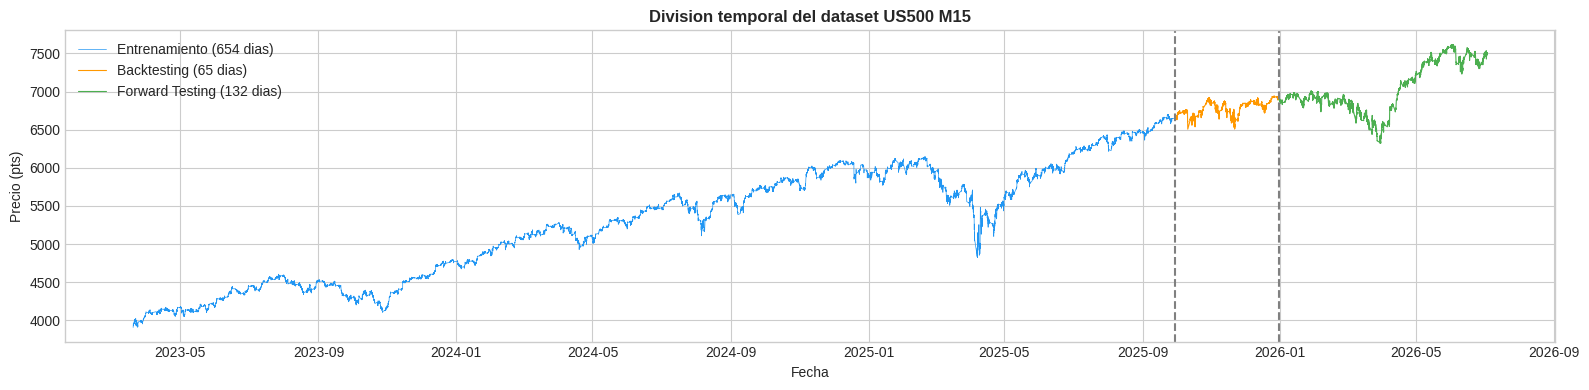

In [ ]:
# ============================================================
# PARTICIÓN TEMPORAL (NO ALEATORIA)
# ============================================================

FECHA_FIN_TRAIN ='2025-09-30'   # Último periodo de train
FECHA_FIN_BT    ='2025-12-31'   # Último periodo de backtesting

#df_train = df[df['time'] < FECHA_CORTE_TRAIN].copy()
#df_forward = df[df['time'] >= FECHA_CORTE_TRAIN].copy()

#print("✂️ PARTICIÓN TEMPORAL REALIZADA")
#print("=" * 60)
#print(f"Train:    {df_train['time'].min()} → {df_train['time'].max()}  ({len(df_train):,} velas)")
#print(f"Forward:  {df_forward['time'].min()} → {df_forward['time'].max()}  ({len(df_forward):,} velas)")
#print(f"\nProporción train/forward: {len(df_train)/len(df):.1%} / {len(df_forward)/len(df):.1%}")



df_train = df[df['time'] <= FECHA_FIN_TRAIN].copy()
df_bt    = df[(df['time'] > FECHA_FIN_TRAIN) & (df['time'] <= FECHA_FIN_BT)].copy()
df_fw    = df[df['time'] > FECHA_FIN_BT].copy()

print("Division temporal:")
print(f"  Entrenamiento : {len(df_train):,} velas | "
      f"{df_train['time'].min().date()} → {df_train['time'].max().date()} | "
      f"{df_train['time'].dt.date.nunique()} dias")
print(f"  Backtesting   : {len(df_bt):,} velas | "
      f"{df_bt['time'].min().date()} → {df_bt['time'].max().date()} | "
      f"{df_bt['time'].dt.date.nunique()} dias")
print(f"  Forward       : {len(df_fw):,} velas | "
      f"{df_fw['time'].min().date()} → {df_fw['time'].max().date()} | "
      f"{df_fw['time'].dt.date.nunique()} dias")

# Visualizacion de la division
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_train['time'], df_train['close'], color='#2196F3', linewidth=0.5,
        label=f'Entrenamiento ({df_train["time"].dt.date.nunique()} dias)')
ax.plot(df_bt['time'], df_bt['close'], color='#FF9800', linewidth=0.8,
        label=f'Backtesting ({df_bt["time"].dt.date.nunique()} dias)')
ax.plot(df_fw['time'], df_fw['close'], color='#4CAF50', linewidth=0.8,
        label=f'Forward Testing ({df_fw["time"].dt.date.nunique()} dias)')
ax.axvline(pd.to_datetime(FECHA_FIN_TRAIN), color='gray',
           linestyle='--', linewidth=1.5)
ax.axvline(pd.to_datetime(FECHA_FIN_BT), color='gray',
           linestyle='--', linewidth=1.5)
ax.set_title('Division temporal del dataset US500 M15', fontsize=12, fontweight='bold')
ax.set_ylabel('Precio (pts)'); ax.set_xlabel('Fecha')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# LIMPIEZA DE DATOS (eliminar NaN generados por los indicadores)
# ============================================================

nan_train_antes = df_train.isna().sum().sum()
nan_forward_antes = df_fw.isna().sum().sum()

df_train_clean = df_train.dropna().copy()
df_forward_clean = df_fw.dropna().copy()

print("🧹 LIMPIEZA DE DATOS")
print("=" * 60)
print(f"Train:    {len(df_train):,} → {len(df_train_clean):,} filas (se eliminan las primeras ~200 velas por el SMA_200)")
print(f"Forward:  {len(df_fw):,} → {len(df_forward_clean):,} filas")

🧹 LIMPIEZA DE DATOS
Train:    59,759 → 59,560 filas (se eliminan las primeras ~200 velas por el SMA_200)
Forward:  12,033 → 12,032 filas


---
# Selección de Features (comparación de métodos)

Se aplican cuatro métodos:

1. **Reducción de multicolinealidad** (filtro, umbral de correlación 0.95)
2. **Random Forest Importance** (embedded, sobre `Target_Return`)
3. **SelectKBest con información mutua** (filtro, relaciones lineales y no lineales)
4. **SelectKBest con correlación de Pearson** (`r_regression`, filtro, relaciones lineales)

In [ ]:
# ============================================================
# PREPARAR MATRIZ DE FEATURES (SOLO CON DATOS DE TRAIN)
# ============================================================

cols_ohlc = ['time', 'open', 'high', 'low', 'close']
cols_target = ['Target_Return', 'Target_Direccion']
feature_cols = [c for c in df.columns if c not in cols_ohlc + cols_target]

X_all = df_train_clean[feature_cols]
y_ret = df_train_clean['Target_Return']

print(f"📊 Total de features disponibles para comparar: {len(feature_cols)}")
print(f"📊 Observaciones de train usadas para la selección: {len(X_all):,}")

📊 Total de features disponibles para comparar: 42
📊 Observaciones de train usadas para la selección: 59,560


In [ ]:
# ============================================================
# MÉTODO 1: REDUCCIÓN DE MULTICOLINEALIDAD
# ============================================================

umbral_corr = 0.95

corr_matrix = X_all.corr().abs()
upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

features_a_eliminar = set()
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if upper_triangle[i, j] and corr_matrix.iloc[i, j] > umbral_corr:
            colj = cols[j]
            if colj not in features_a_eliminar:
                features_a_eliminar.add(colj)

features_multicol = [c for c in feature_cols if c not in features_a_eliminar]

print(f"📊 Features originales:      {len(feature_cols)}")
print(f"📊 Features eliminadas (|correlación| > {umbral_corr}): {len(features_a_eliminar)}")
print(f"📊 Features supervivientes:  {len(features_multicol)}")
print(f"\nEliminadas: {sorted(features_a_eliminar)}")

N = len(features_multicol)
print(f"\n➡️ N = {N}: este será el número de features que se seleccionará con cada método siguiente")

📊 Features originales:      42
📊 Features eliminadas (|correlación| > 0.95): 20
📊 Features supervivientes:  22

Eliminadas: ['ATR_Pct', 'BB_PercentB_20', 'BB_Width_20', 'Donchian_Lower_10', 'Donchian_Lower_20', 'Donchian_Lower_55', 'Donchian_Mid_10', 'Donchian_Mid_20', 'Donchian_Mid_55', 'Donchian_Upper_10', 'Donchian_Upper_20', 'Donchian_Upper_55', 'EMA_20', 'EMA_50', 'MACD_Signal', 'MOM_10', 'SMA_100', 'SMA_200', 'SMA_50', 'WILLR_14']

➡️ N = 22: este será el número de features que se seleccionará con cada método siguiente


In [ ]:
# ============================================================
# MÉTODO 2: RANDOM FOREST IMPORTANCE (embedded)
# ============================================================

rf_reg = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf_reg.fit(X_all, y_ret)

importancias_rf = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=False)
features_rf = importancias_rf.head(N).index.tolist()

print("✅ Random Forest entrenado para calcular importancias")
importancias_rf.head(15)

✅ Random Forest entrenado para calcular importancias


,0
ATR_14,0.185316
ATR_Pct,0.097291
Dist_Close_SMA200,0.052337
CCI_14,0.047155
SMA_50,0.043139
ROC_10,0.037942
Donchian_Width_10,0.034241
EMA_50,0.033208
MACD_Hist,0.025973
MOM_10,0.024653


In [ ]:
# ============================================================
# MÉTODO 3: SELECTKBEST CON INFORMACIÓN MUTUA
# ============================================================

selector_mi = SelectKBest(score_func=mutual_info_regression, k=N)
selector_mi.fit(X_all, y_ret)

mi_scores = pd.Series(selector_mi.scores_, index=feature_cols).sort_values(ascending=False)
features_mi = mi_scores.head(N).index.tolist()

print("✅ Información mutua calculada")
mi_scores.head(15)

✅ Información mutua calculada


,0
Donchian_Upper_55,1.010273
Donchian_Lower_55,0.974841
Donchian_Mid_55,0.911385
Donchian_Upper_20,0.904504
EMA_20,0.891062
Donchian_Lower_20,0.883626
EMA_50,0.879917
SMA_20,0.877190
Donchian_Mid_20,0.876738
Donchian_Upper_10,0.870916


In [ ]:
# ============================================================
# MÉTODO 4: SELECTKBEST CON CORRELACIÓN DE PEARSON (r_regression)
# ============================================================

selector_r = SelectKBest(score_func=r_regression, k=N)
selector_r.fit(X_all, y_ret)

r_scores = pd.Series(np.abs(selector_r.scores_), index=feature_cols).sort_values(ascending=False)
features_r = r_scores.head(N).index.tolist()

print("✅ Correlación de Pearson calculada")
r_scores.head(15)

✅ Correlación de Pearson calculada


,0
BB_Width_20,0.021715
Donchian_Width_20,0.019871
ATR_Pct,0.019164
ATR_14,0.017030
Donchian_Width_10,0.015038
Donchian_Width_55,0.010557
Donchian_Breakout_Up_20,0.008354
Dist_Close_SMA200,0.007806
MACD_Signal,0.006078
MACD_Line,0.005937


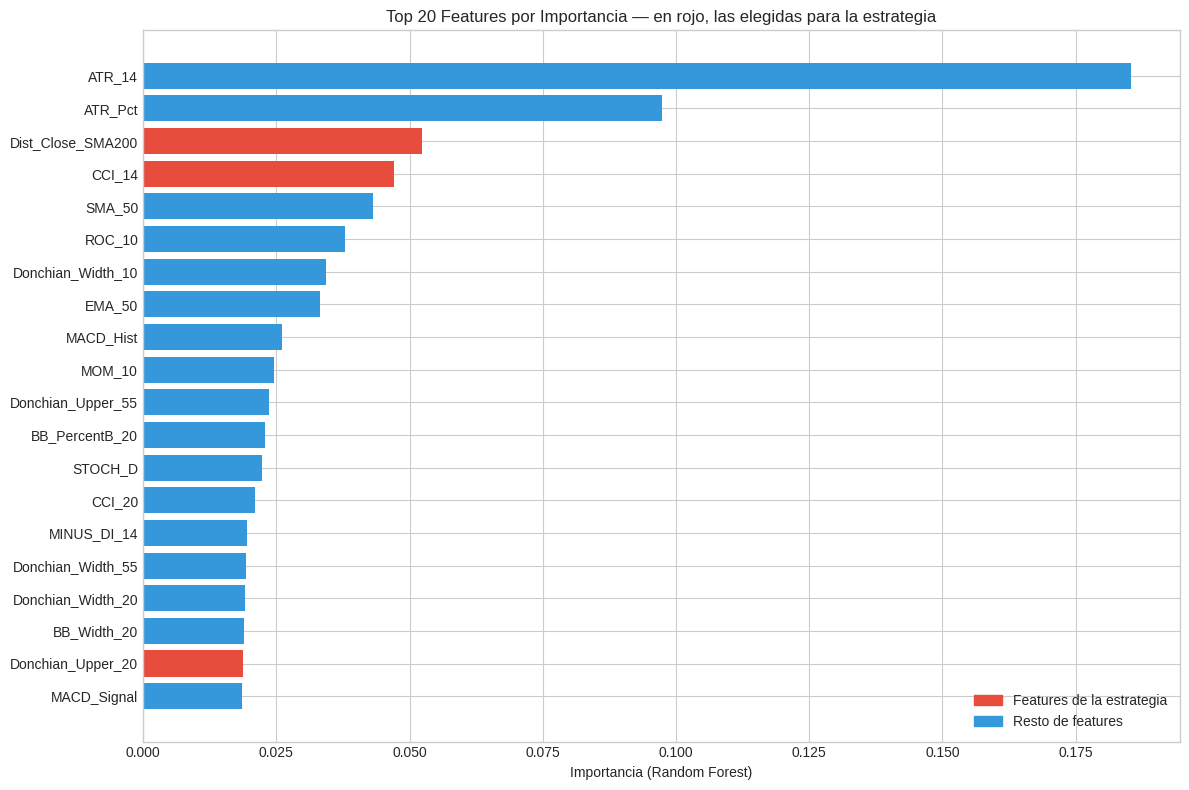

In [ ]:
# ============================================================
# GRÁFICO: TOP 20 FEATURES POR RANDOM FOREST IMPORTANCE
# (se resaltan en color distinto las features elegidas para la estrategia)
# ============================================================

FEATURES_ESTRATEGIA = ['CCI_14', 'Dist_Close_SMA200', 'Donchian_Breakout_Up_20',
                        'Donchian_Breakout_Down_20', 'Donchian_Upper_20', 'Donchian_Lower_20']

top_20 = importancias_rf.head(20)
colores = ['#e74c3c' if feat in FEATURES_ESTRATEGIA else '#3498db' for feat in top_20.index]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(top_20)), top_20.values, color=colores)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20.index)
ax.invert_yaxis()
ax.set_xlabel('Importancia (Random Forest)')
ax.set_title('Top 20 Features por Importancia — en rojo, las elegidas para la estrategia')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#e74c3c', label='Features de la estrategia'),
                    Patch(color='#3498db', label='Resto de features')], loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# COMPARACIÓN ENTRE MÉTODOS:
# ============================================================

selecciones = {
    'Multicolinealidad': features_multicol,
    'RF_Importance': features_rf,
    'mutual_info': features_mi,
    'r_regression': features_r,
}

rank_rf = importancias_rf.rank(ascending=False).astype(int)

print("=" * 78)
print(f"{'Feature':<28}{'¿Sobrevive?':<14}{'¿En RF top-N?':<16}{'¿En MI top-N?':<16}{'Rank RF':<10}")
print("=" * 78)
for feat in FEATURES_ESTRATEGIA:
    sobrevive = 'Sí' if feat in features_multicol else 'No'
    en_rf = 'Sí' if feat in features_rf else 'No'
    en_mi = 'Sí' if feat in features_mi else 'No'
    rank = rank_rf.get(feat, np.nan)
    print(f"{feat:<28}{sobrevive:<14}{en_rf:<16}{en_mi:<16}{rank:<10}")

Feature                     ¿Sobrevive?   ¿En RF top-N?   ¿En MI top-N?   Rank RF   
CCI_14                      Sí            Sí              No              4         
Dist_Close_SMA200           Sí            Sí              No              3         
Donchian_Breakout_Up_20     Sí            No              No              41        
Donchian_Breakout_Down_20   Sí            No              No              37        
Donchian_Upper_20           No            Sí              Sí              19        
Donchian_Lower_20           No            No              Sí              35        


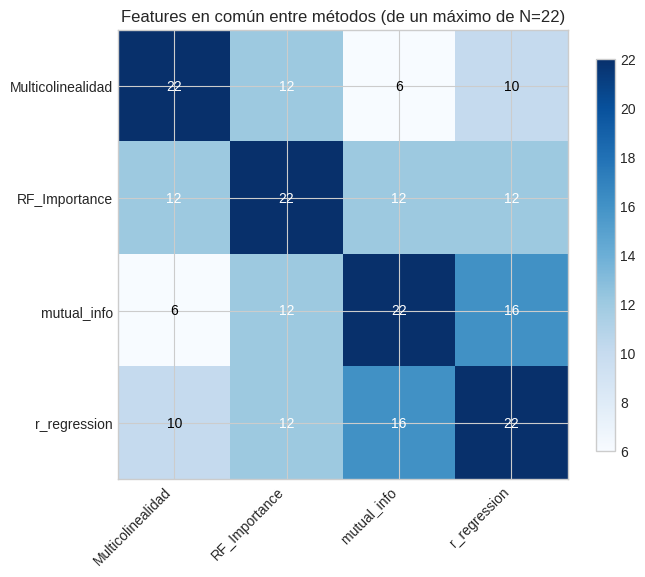

In [ ]:
# ============================================================
# HEATMAP DE SOLAPAMIENTO ENTRE MÉTODOS
# ============================================================

nombres = list(selecciones.keys())
n_metodos = len(nombres)
solapamiento = np.zeros((n_metodos, n_metodos))

for i, m1 in enumerate(nombres):
    for j, m2 in enumerate(nombres):
        solapamiento[i, j] = len(set(selecciones[m1]) & set(selecciones[m2]))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(solapamiento, cmap='Blues')
ax.set_xticks(range(n_metodos)); ax.set_xticklabels(nombres, rotation=45, ha='right')
ax.set_yticks(range(n_metodos)); ax.set_yticklabels(nombres)
for i in range(n_metodos):
    for j in range(n_metodos):
        ax.text(j, i, int(solapamiento[i, j]), ha='center', va='center',
                 color='white' if solapamiento[i, j] > N/2 else 'black')
ax.set_title(f'Features en común entre métodos (de un máximo de N={N})')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

---
#  Justificación de la Configuración Elegida para la Estrategia

**Indicadores seleccionados por el estudiante:** Donchian(20), CCI(14) y SMA(200).

Los resultados de la Parte 4 permiten justificar esta elección con evidencia cuantitativa:

- **CCI_14** aparece de forma consistente entre las primeras posiciones del ranking de Random Forest Importance
  (dentro del top 5 de 42 features analizadas) y sobrevive al filtro de multicolinealidad. Esto indica que el nivel
  del CCI(14) aporta información no redundante y relevante sobre el retorno futuro, lo que respalda su uso como
  **gatillo** de entrada.

- **Dist_Close_SMA200** (la distancia relativa del precio respecto a la SMA de 200 periodos) también se sitúa
  entre las variables más importantes según Random Forest y sobrevive a la reducción de multicolinealidad. Esto
  respalda el uso de la SMA(200) como **filtro de contexto/tendencia**: no se opera en la dirección de la señal si
  el precio no está confirmando esa misma tendencia de fondo.

- Las variables de **nivel de precio sin transformar** (SMA_20, SMA_50, SMA_200, los propios canales
  Donchian_Upper/Lower/Mid) son eliminadas por el filtro de multicolinealidad, ya que están altísimamente
  correlacionadas entre sí y con el propio precio de cierre (todas se mueven de forma casi idéntica en escala de
  precio). Esto no invalida al Donchian de 20 periodos: indica que su valor informativo no está en el nivel
  absoluto del canal, sino en el **evento discreto de ruptura** (Donchian_Breakout_Up_20 /
  Donchian_Breakout_Down_20), que es justamente la forma en que se usa dentro de la estrategia.

- Las variables de ruptura (Donchian_Breakout_Up_20, Donchian_Breakout_Down_20) son eventos binarios poco
  frecuentes (ocurren en menos del 10% de las velas), por lo que, de forma esperable, obtienen una importancia
  media baja en un ranking calculado sobre todas las velas del histórico: un evento raro no puede explicar la
  varianza del retorno "en promedio", aunque sea muy informativo en el instante exacto en el que ocurre. Por esa
  razón, su valor no debe juzgarse solo por su ranking de importancia general, sino por lo que representan: el
  momento concreto en el que el precio confirma una ruptura de rango, que es precisamente el papel que cumplen en
  la estrategia (definir el instante de entrada, no predecir el retorno medio de cualquier vela).

- La comparación entre métodos muestra que las features de la estrategia se repiten en más de uno de los cuatro
  métodos aplicados (multicolinealidad, RF importance, información mutua y correlación de Pearson), lo que reduce
  el riesgo de haber elegido variables relevantes solo por azar o por las particularidades de un único método.

**Conclusión de esta sección:** la combinación Donchian(20) + CCI(14) + SMA(200) no es arbitraria. Sus componentes
continuos (CCI_14, Dist_Close_SMA200) figuran entre los indicadores estadísticamente más relevantes de toda la
batería analizada, y su componente discreto (la ruptura del canal) representa el mecanismo mediante el cual esos
indicadores se traducen en un momento concreto de entrada al mercado.

---
#Preparación de Datos para el Modelo Random Forest (validación ML)

Antes de construir la estrategia basada en reglas, se entrena —igual que en `Ejercicio_RF_Estudiantes`— un
**Random Forest de clasificación** que sirve como modelo de referencia (benchmark de Machine Learning) frente al
cual comparar la estrategia basada en reglas. Se utiliza el conjunto de `N` features que sobrevivió al filtro de
multicolinealidad, ya que es el que mejor equilibrio muestra entre reducir redundancia y mantener información
relevante (incluye tanto `CCI_14` como `Dist_Close_SMA200`).

In [ ]:
# ============================================================
# SELECCIÓN FINAL DE FEATURES PARA EL MODELO RF
# ============================================================

features_seleccionadas = features_multicol
print(f"✅ Se usarán {len(features_seleccionadas)} features (conjunto sin multicolinealidad) para el modelo Random Forest")

X_train = df_train_clean[features_seleccionadas]
y_train = df_train_clean['Target_Direccion']
X_forward = df_forward_clean[features_seleccionadas]
y_forward = df_forward_clean['Target_Direccion']

print(f"X_train:   {X_train.shape}")
print(f"X_forward: {X_forward.shape}")

✅ Se usarán 22 features (conjunto sin multicolinealidad) para el modelo Random Forest
X_train:   (59560, 22)
X_forward: (12032, 22)


---
#  Configuración y Entrenamiento del Random Forest

Se eligen n_estimators = 300 y max_depth = 2. Un número de árboles relativamente alto (300) aporta
estabilidad a las importancias y a las probabilidades estimadas sin encarecer demasiado el entrenamiento; una
profundidad baja (2) limita la capacidad del modelo para memorizar el ruido de mercados financieros, que son
notoriamente poco predecibles a nivel de vela a vela.

In [ ]:
# ============================================================
# CONFIGURAR Y ENTRENAR EL RANDOM FOREST
# ============================================================

n_estimators = 300
max_depth = 2

modelo_rf = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)
print("✅ Modelo entrenado correctamente")
print(f"   usando {len(features_seleccionadas)} features y {len(X_train):,} observaciones de train")

✅ Modelo entrenado correctamente
   usando 22 features y 59,560 observaciones de train


---
#Umbral de Probabilidad y Señales del Modelo ML

Se obtienen las probabilidades del modelo para la clase "sube" y se elige un umbral de decisión. Se inspecciona
la distribución de probabilidades en train para decidir un umbral que favorezca la precisión sobre la cantidad
de señales.

📊 Estadísticas de la distribución de probabilidades (train)
count    59560.000000
mean         0.494956
std          0.010842
min          0.456880
25%          0.487026
50%          0.496420
75%          0.503075
max          0.521906
dtype: float64


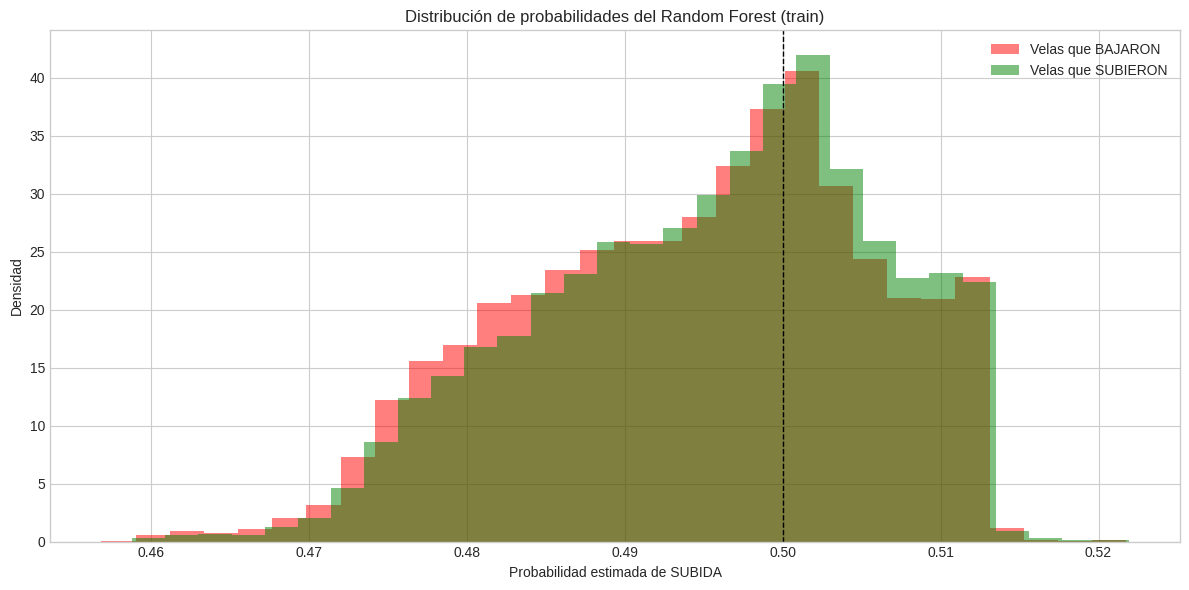

In [ ]:
# ============================================================
# PROBABILIDADES EN TRAIN Y DISTRIBUCIÓN
# ============================================================

probs_train = modelo_rf.predict_proba(X_train)[:, 1]

print("📊 Estadísticas de la distribución de probabilidades (train)")
print(pd.Series(probs_train).describe())

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(probs_train[y_train == 0], bins=30, alpha=0.5, label='Velas que BAJARON', color='red', density=True)
ax.hist(probs_train[y_train == 1], bins=30, alpha=0.5, label='Velas que SUBIERON', color='green', density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Probabilidad estimada de SUBIDA')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de probabilidades del Random Forest (train)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# UMBRAL DE PROBABILIDAD ELEGIDO
# ============================================================

UMBRAL = 0.50

print(f"✅ Umbral seleccionado: {UMBRAL}")
print(f"   Si P(SUBE) >= {UMBRAL} → se predice SUBE (1)")
print(f"   Si P(SUBE) <  {UMBRAL} → se predice BAJA (0)")
print("\nComo se observa en el histograma anterior, las probabilidades quedan concentradas en una banda muy "
      "estrecha alrededor de 0.50 (típico en la predicción de la dirección de la siguiente vela en mercados "
      "financieros muy eficientes). Umbrales notablemente por encima de 0.50 dejarían casi sin señales de subida "
      "al modelo (un sesgo casi permanente hacia una sola clase), por lo que se mantiene el umbral en 0.50 para "
      "conservar un modelo balanceado y comparable de forma justa con la estrategia de reglas.")

✅ Umbral seleccionado: 0.5
   Si P(SUBE) >= 0.5 → se predice SUBE (1)
   Si P(SUBE) <  0.5 → se predice BAJA (0)

Como se observa en el histograma anterior, las probabilidades quedan concentradas en una banda muy estrecha alrededor de 0.50 (típico en la predicción de la dirección de la siguiente vela en mercados financieros muy eficientes). Umbrales notablemente por encima de 0.50 dejarían casi sin señales de subida al modelo (un sesgo casi permanente hacia una sola clase), por lo que se mantiene el umbral en 0.50 para conservar un modelo balanceado y comparable de forma justa con la estrategia de reglas.


---
#  Evaluación del Modelo Random Forest (train vs forward)

Se generan las predicciones, se convierten en señales (+1/-1) y se calculan accuracy y matrices de confusión en
ambos periodos, para detectar posible sobreajuste antes de comparar este modelo con la estrategia de reglas.

In [ ]:
# ============================================================
# PROBABILIDADES, PREDICCIONES Y SEÑALES (TRAIN Y FORWARD)
# ============================================================

probs_forward = modelo_rf.predict_proba(X_forward)[:, 1]

y_pred_train = (probs_train >= UMBRAL).astype(int)
y_pred_forward = (probs_forward >= UMBRAL).astype(int)

senal_train_rf = 2 * y_pred_train - 1
senal_forward_rf = 2 * y_pred_forward - 1

print("✅ Predicciones y señales generadas para el modelo Random Forest")

✅ Predicciones y señales generadas para el modelo Random Forest


In [ ]:
# ============================================================
# ACCURACY Y ANÁLISIS DE SOBREAJUSTE
# ============================================================

acc_train = accuracy_score(y_train, y_pred_train)
acc_forward = accuracy_score(y_forward, y_pred_forward)
diferencia = acc_train - acc_forward

print("📊 ACCURACY")
print("=" * 60)
print(f"Train:    {acc_train:.4f}")
print(f"Forward:  {acc_forward:.4f}")
print(f"Diferencia: {diferencia:.2%}")

if diferencia > 0.10:
    print("\n⚠️ ALERTA: posible sobreajuste significativo")
elif diferencia > 0.05:
    print("\n⚡ ADVERTENCIA: cierto grado de sobreajuste")
else:
    print("\n✅ La diferencia entre train y forward es moderada")

📊 ACCURACY
Train:    0.5205
Forward:  0.5002
Diferencia: 2.03%

✅ La diferencia entre train y forward es moderada


In [ ]:
# ============================================================
# MATRICES DE CONFUSIÓN
# ============================================================

cm_train = confusion_matrix(y_train, y_pred_train)
cm_forward = confusion_matrix(y_forward, y_pred_forward)

print("TRAIN:")
print("                PREDICCIÓN")
print("               BAJA    SUBE")
print(f"      BAJA   [{cm_train[0,0]:5d}   {cm_train[0,1]:5d}]")
print(f"      SUBE   [{cm_train[1,0]:5d}   {cm_train[1,1]:5d}]")

print("\nFORWARD:")
print("                PREDICCIÓN")
print("               BAJA    SUBE")
print(f"      BAJA   [{cm_forward[0,0]:5d}   {cm_forward[0,1]:5d}]")
print(f"      SUBE   [{cm_forward[1,0]:5d}   {cm_forward[1,1]:5d}]")

TRAIN:
                PREDICCIÓN
               BAJA    SUBE
      BAJA   [19407   10676]
      SUBE   [17882   11595]

FORWARD:
                PREDICCIÓN
               BAJA    SUBE
      BAJA   [ 3078    2951]
      SUBE   [ 3062    2941]


---
#Construcción de la Estrategia Basada en Reglas

Se implementa ahora, de forma explícita, la estrategia definida:


LARGO:  Donchian_Breakout_Up_20   AND   CCI14_Cross_Up_200    AND   close > SMA_200

CORTO:  Donchian_Breakout_Down_20 AND   CCI14_Cross_Down_200  AND   close < SMA_200


In [ ]:
# ============================================================
# CONSTRUCCIÓN DE LA MÁSCARA DE SEÑALES SOBRE TODO EL DATASET LIMPIO
# ============================================================

df_estrategia = df.dropna(subset=['SMA_200', 'Donchian_Upper_20', 'Donchian_Lower_20',
                                    'CCI_14', 'Target_Return']).copy().reset_index(drop=True)

long_cond = (
    (df_estrategia['Donchian_Breakout_Up_20'] == 1) &
    (df_estrategia['CCI14_Cross_Up_200'] == 1) &
    (df_estrategia['close'] > df_estrategia['SMA_200'])
)

short_cond = (
    (df_estrategia['Donchian_Breakout_Down_20'] == 1) &
    (df_estrategia['CCI14_Cross_Down_200'] == 1) &
    (df_estrategia['close'] < df_estrategia['SMA_200'])
)

df_estrategia['senal_entrada'] = 0
df_estrategia.loc[long_cond, 'senal_entrada'] = 1
df_estrategia.loc[short_cond, 'senal_entrada'] = -1

print(f"📈 Señales de entrada en LARGO:  {(df_estrategia['senal_entrada'] == 1).sum()}")
print(f"📉 Señales de entrada en CORTO:  {(df_estrategia['senal_entrada'] == -1).sum()}")
print(f"📊 Total de velas analizadas:    {len(df_estrategia):,}")

📈 Señales de entrada en LARGO:  768
📉 Señales de entrada en CORTO:  607
📊 Total de velas analizadas:    77,491


In [ ]:
# ============================================================
# POSICIÓN: SE MANTIENE HASTA LA SIGUIENTE SEÑAL CONTRARIA
# ============================================================

df_estrategia['posicion'] = (
    df_estrategia['senal_entrada']
    .replace(0, np.nan)
    .ffill()
    .fillna(0)
)

df_estrategia['retorno_sistema'] = df_estrategia['posicion'] * df_estrategia['Target_Return']

print("✅ Posición y retorno del sistema calculados")
print(df_estrategia[['time', 'close', 'senal_entrada', 'posicion', 'retorno_sistema']].tail())

✅ Posición y retorno del sistema calculados
                     time   close  senal_entrada  posicion  retorno_sistema
77486 2026-07-03 18:30:00  7504.3              0       1.0         0.000173
77487 2026-07-03 18:45:00  7505.6              0       1.0        -0.000240
77488 2026-07-03 19:00:00  7503.8              0       1.0        -0.000293
77489 2026-07-03 19:15:00  7501.6              0       1.0         0.000480
77490 2026-07-03 19:30:00  7505.2              0       1.0        -0.000253


---
#  Visualización de las Señales sobre el Precio

Se muestra un tramo reciente de velas (las últimas ~2.000, aproximadamente un mes de operativa) con la SMA(200),
el canal Donchian(20) y flechas verdes (▲) marcando el cumplimiento de la condición de LARGO y flechas rojas (▼)
marcando el cumplimiento de la condición de CORTO. Se elige un tramo reciente, en lugar de todo el histórico.

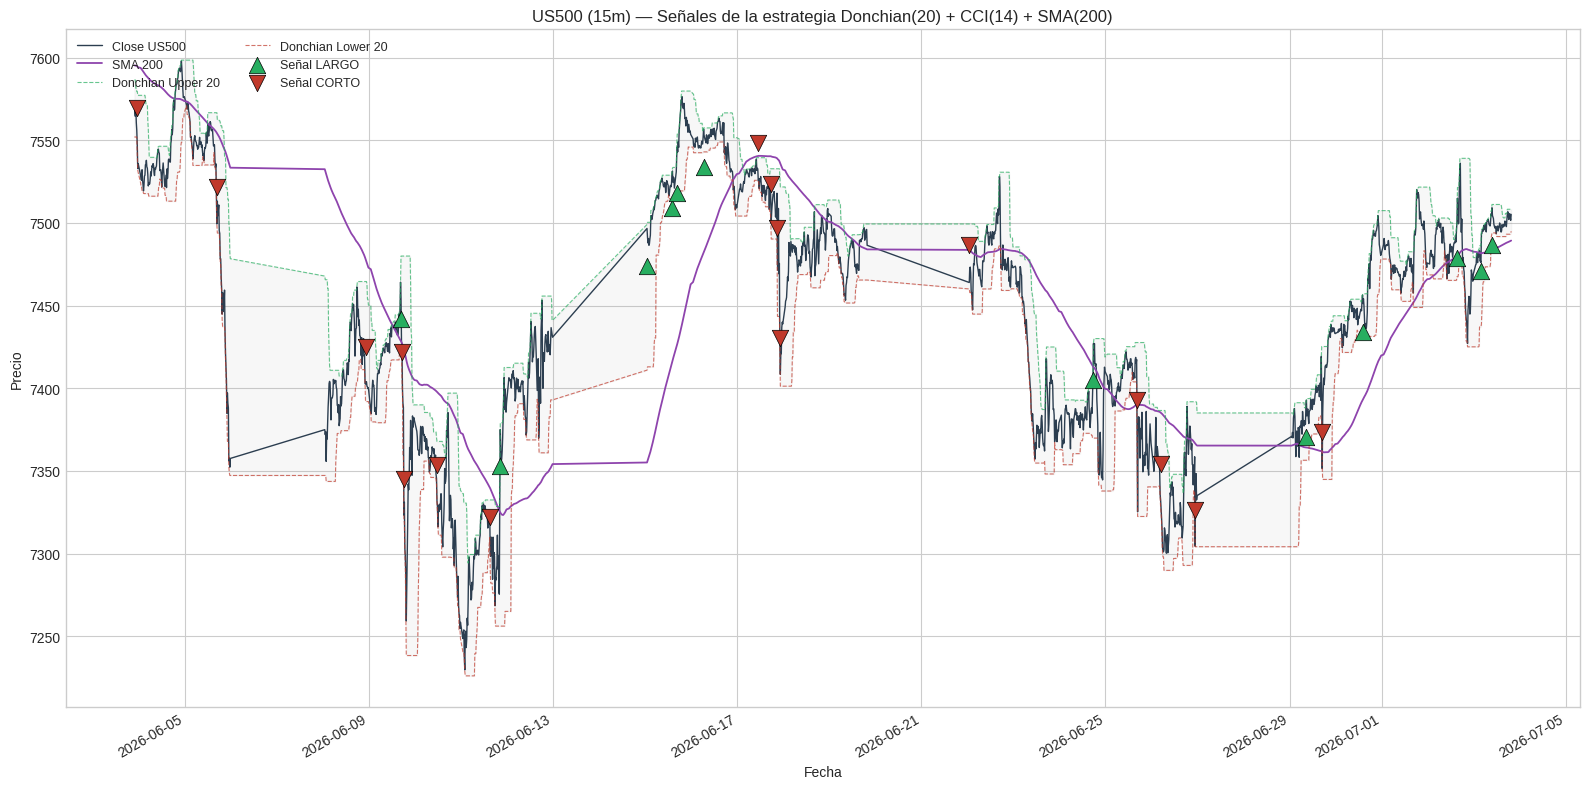

In [ ]:
# ============================================================
# GRÁFICO: PRECIO + SMA200 + DONCHIAN(20) + FLECHAS DE SEÑALES
# ============================================================

ventana = df_estrategia.tail(2000).copy()

fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(ventana['time'], ventana['close'], color='#2c3e50', linewidth=1, label='Close US500')
ax.plot(ventana['time'], ventana['SMA_200'], color='#8e44ad', linewidth=1.3, label='SMA 200')
ax.plot(ventana['time'], ventana['Donchian_Upper_20'], color='#27ae60', linewidth=0.8, linestyle='--', alpha=0.7, label='Donchian Upper 20')
ax.plot(ventana['time'], ventana['Donchian_Lower_20'], color='#c0392b', linewidth=0.8, linestyle='--', alpha=0.7, label='Donchian Lower 20')
ax.fill_between(ventana['time'], ventana['Donchian_Lower_20'], ventana['Donchian_Upper_20'], color='gray', alpha=0.06)

largos = ventana[ventana['senal_entrada'] == 1]
cortos = ventana[ventana['senal_entrada'] == -1]

ax.scatter(largos['time'], largos['close'] * 0.997, marker='^', color='#27ae60', s=140,
           label='Señal LARGO', zorder=5, edgecolor='black', linewidth=0.5)
ax.scatter(cortos['time'], cortos['close'] * 1.003, marker='v', color='#c0392b', s=140,
           label='Señal CORTO', zorder=5, edgecolor='black', linewidth=0.5)

ax.set_title('US500 (15m) — Señales de la estrategia Donchian(20) + CCI(14) + SMA(200)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio')
ax.legend(loc='upper left', ncol=2, fontsize=9)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
# Backtesting de la Estrategia (train vs forward)

Se calcula la curva de equity de la estrategia en train y forward, junto con las principales métricas de
rendimiento y riesgo, y se compara además con una variante **solo largos** (ignorando las señales de corto), que
permite entender mejor de dónde procede el resultado final.

In [ ]:
# ============================================================
# FUNCIÓN DE MÉTRICAS DE BACKTEST
# ============================================================

def metricas_backtest(d, columna_retorno='retorno_sistema', columna_posicion='posicion'):
    equity = (1 + d[columna_retorno]).cumprod()
    dd = equity / equity.cummax() - 1
    years = (d['time'].max() - d['time'].min()).days / 365.25
    bars_per_year = len(d) / years if years > 0 else np.nan
    std = d[columna_retorno].std()
    sharpe = (d[columna_retorno].mean() / std * np.sqrt(bars_per_year)) if std > 0 else np.nan
    n_cambios = (d[columna_posicion].diff() != 0).sum()
    return {
        'retorno_total': equity.iloc[-1] - 1,
        'max_drawdown': dd.min(),
        'sharpe_aprox': sharpe,
        'n_cambios_posicion': n_cambios,
        'equity': equity,
    }

df_train_est = df_estrategia[df_estrategia['time'] < FECHA_FIN_TRAIN].copy()
df_forward_est = df_estrategia[df_estrategia['time'] >= FECHA_FIN_TRAIN].copy()

res_train = metricas_backtest(df_train_est)
res_forward = metricas_backtest(df_forward_est)

bh_train = (1 + df_train_est['Target_Return']).cumprod()
bh_forward = (1 + df_forward_est['Target_Return']).cumprod()

print("=" * 70)
print(f"{'' :<22}{'TRAIN':>15}{'FORWARD':>15}")
print("-" * 70)
print(f"{'Retorno estrategia':<22}{res_train['retorno_total']:>14.2%} {res_forward['retorno_total']:>14.2%}")
print(f"{'Retorno Buy & Hold':<22}{bh_train.iloc[-1]-1:>14.2%} {bh_forward.iloc[-1]-1:>14.2%}")
print(f"{'Max Drawdown':<22}{res_train['max_drawdown']:>14.2%} {res_forward['max_drawdown']:>14.2%}")
print(f"{'Sharpe aprox.':<22}{res_train['sharpe_aprox']:>14.2f} {res_forward['sharpe_aprox']:>14.2f}")
print(f"{'Cambios de posición':<22}{res_train['n_cambios_posicion']:>14.0f} {res_forward['n_cambios_posicion']:>14.0f}")

                                TRAIN        FORWARD
----------------------------------------------------------------------
Retorno estrategia             2.71%         -8.72%
Retorno Buy & Hold            66.24%         12.73%
Max Drawdown                 -21.21%        -15.84%
Sharpe aprox.                   0.15          -0.70
Cambios de posición              337            115


In [ ]:
# ============================================================
# VARIANTE SOLO-LARGOS (comparación adicional)
# Ignora las señales de corto: se pone plano cuando aparece una señal de corto
# en vez de abrir posición corta, y solo entra al aparecer una señal de largo.
# ============================================================

pos_solo_largos = pd.Series(np.nan, index=df_estrategia.index)
pos_solo_largos[df_estrategia['senal_entrada'] == 1] = 1
pos_solo_largos[df_estrategia['senal_entrada'] == -1] = 0
pos_solo_largos = pos_solo_largos.ffill().fillna(0)

df_estrategia['posicion_solo_largos'] = pos_solo_largos
df_estrategia['retorno_solo_largos'] = df_estrategia['posicion_solo_largos'] * df_estrategia['Target_Return']

df_train_est['posicion_solo_largos'] = df_estrategia.loc[df_train_est.index, 'posicion_solo_largos']
df_train_est['retorno_solo_largos'] = df_estrategia.loc[df_train_est.index, 'retorno_solo_largos']
df_forward_est['posicion_solo_largos'] = df_estrategia.loc[df_forward_est.index, 'posicion_solo_largos']
df_forward_est['retorno_solo_largos'] = df_estrategia.loc[df_forward_est.index, 'retorno_solo_largos']

res_train_lo = metricas_backtest(df_train_est, 'retorno_solo_largos', 'posicion_solo_largos')
res_forward_lo = metricas_backtest(df_forward_est, 'retorno_solo_largos', 'posicion_solo_largos')

print("Variante SOLO-LARGOS (misma lógica de entrada, sin operar en corto)")
print("=" * 70)
print(f"{'':<22}{'TRAIN':>15}{'FORWARD':>15}")
print("-" * 70)
print(f"{'Retorno solo-largos':<22}{res_train_lo['retorno_total']:>14.2%} {res_forward_lo['retorno_total']:>14.2%}")
print(f"{'Max Drawdown':<22}{res_train_lo['max_drawdown']:>14.2%} {res_forward_lo['max_drawdown']:>14.2%}")
print(f"{'Sharpe aprox.':<22}{res_train_lo['sharpe_aprox']:>14.2f} {res_forward_lo['sharpe_aprox']:>14.2f}")

Variante SOLO-LARGOS (misma lógica de entrada, sin operar en corto)
                                TRAIN        FORWARD
----------------------------------------------------------------------
Retorno solo-largos           34.13%          2.03%
Max Drawdown                 -14.92%        -10.10%
Sharpe aprox.                   1.23           0.33


---
#  Comparación Final — Estrategia de Reglas vs Random Forest vs Buy & Hold

Se construye la curva de equity conjunta (train seguido de forward) para las tres aproximaciones: la estrategia
de reglas (Donchian + CCI + SMA200), el modelo Random Forest , y Buy & Hold, con el fin de disponer
de una comparación visual directa que sirva de base para juzgar si la estrategia aporta valor frente a las
alternativas.

In [ ]:
# ============================================================
# CURVA DE EQUITY DEL MODELO RANDOM FOREST (train + forward)
# ============================================================

df_train_clean = df_train_clean.reset_index(drop=True)
df_forward_clean = df_forward_clean.reset_index(drop=True)

df_train_clean['retorno_rf'] = senal_train_rf * df_train_clean['Target_Return']
df_forward_clean['retorno_rf'] = senal_forward_rf * df_forward_clean['Target_Return']

equity_rf_train = (1 + df_train_clean['retorno_rf']).cumprod()
equity_rf_forward = (1 + df_forward_clean['retorno_rf']).cumprod() * equity_rf_train.iloc[-1]

equity_est_train = res_train['equity']
equity_est_forward = res_forward['equity'] * equity_est_train.iloc[-1]

equity_lo_train = res_train_lo['equity']
equity_lo_forward = res_forward_lo['equity'] * equity_lo_train.iloc[-1]

bh_forward_enlazado = bh_forward * bh_train.iloc[-1]

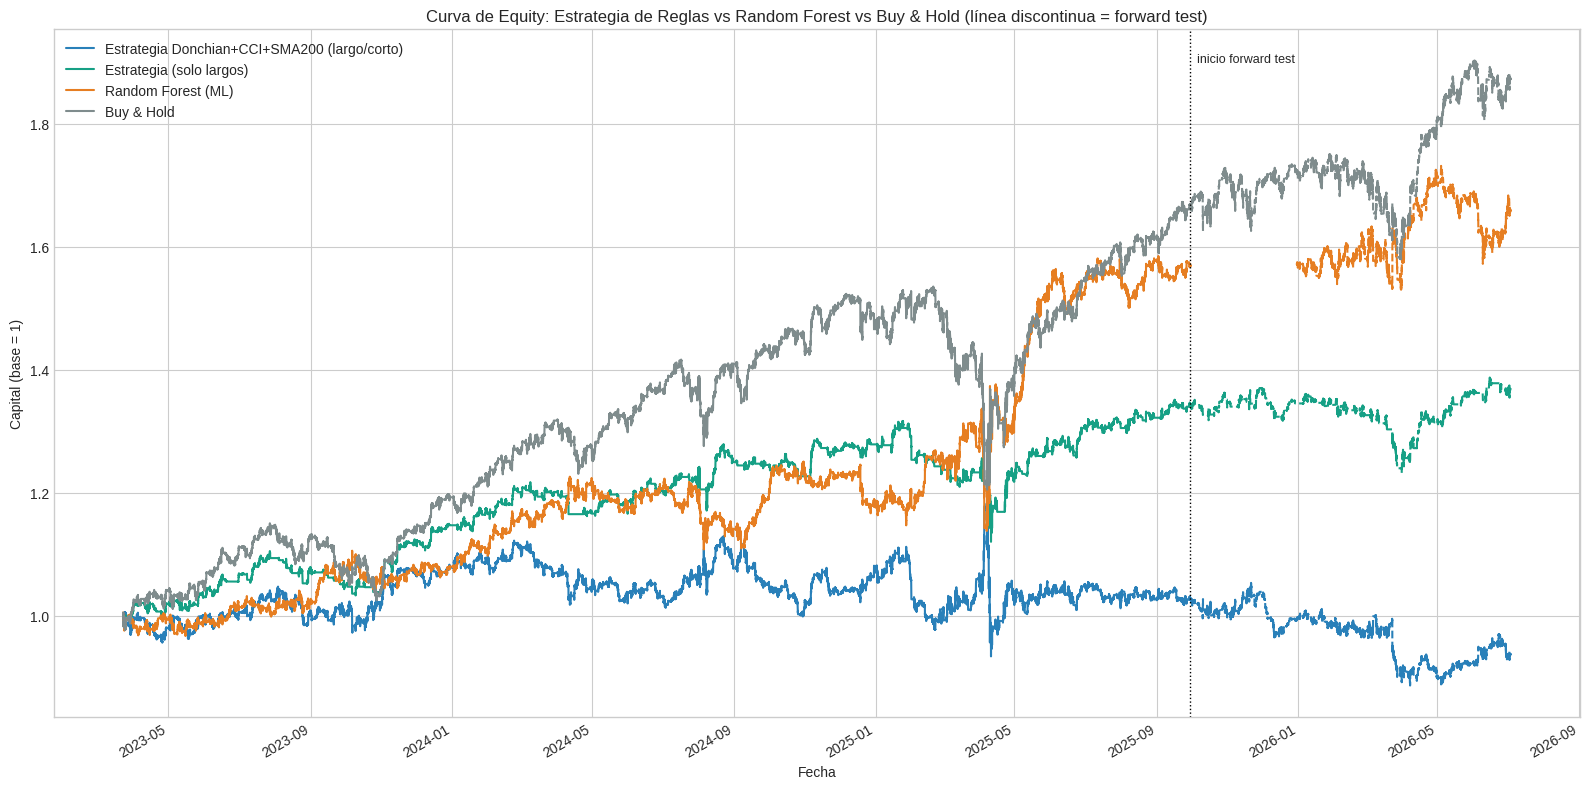

In [ ]:
# ============================================================
# GRÁFICO COMPARATIVO DE CURVAS DE EQUITY
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(df_train_est['time'], equity_est_train, color='#2980b9', label='Estrategia Donchian+CCI+SMA200 (largo/corto)')
ax.plot(df_forward_est['time'], equity_est_forward, color='#2980b9', linestyle='--')

ax.plot(df_train_est['time'], equity_lo_train, color='#16a085', label='Estrategia (solo largos)')
ax.plot(df_forward_est['time'], equity_lo_forward, color='#16a085', linestyle='--')

ax.plot(df_train_clean['time'], equity_rf_train, color='#e67e22', label='Random Forest (ML)')
ax.plot(df_forward_clean['time'], equity_rf_forward, color='#e67e22', linestyle='--')

ax.plot(df_train_est['time'], bh_train, color='#7f8c8d', label='Buy & Hold')
ax.plot(df_forward_est['time'], bh_forward_enlazado, color='#7f8c8d', linestyle='--')

ax.axvline(pd.Timestamp(FECHA_FIN_TRAIN), color='black', linestyle=':', linewidth=1)
ax.text(pd.Timestamp(FECHA_FIN_TRAIN), ax.get_ylim()[1]*0.98, '  inicio forward test', fontsize=9, va='top')

ax.set_title('Curva de Equity: Estrategia de Reglas vs Random Forest vs Buy & Hold (línea discontinua = forward test)')
ax.set_ylabel('Capital (base = 1)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TABLA RESUMEN FINAL
# ============================================================

resumen = pd.DataFrame({
    'Estrategia (largo/corto)': [res_train['retorno_total'], res_forward['retorno_total']],
    'Estrategia (solo largos)': [res_train_lo['retorno_total'], res_forward_lo['retorno_total']],
    'Random Forest (ML)': [equity_rf_train.iloc[-1]-1, equity_rf_forward.iloc[-1]/equity_rf_train.iloc[-1]-1],
    'Buy & Hold': [bh_train.iloc[-1]-1, bh_forward.iloc[-1]-1],
}, index=['Train', 'Forward']).T

try:
    resumen_fmt = resumen.map(lambda x: f"{x:.2%}")
except AttributeError:
    resumen_fmt = resumen.applymap(lambda x: f"{x:.2%}")
print("📊 RETORNO TOTAL POR ENFOQUE")
print("=" * 60)
print(resumen_fmt)

📊 RETORNO TOTAL POR ENFOQUE
                           Train Forward
Estrategia (largo/corto)   2.71%  -8.72%
Estrategia (solo largos)  34.13%   2.03%
Random Forest (ML)        57.04%   5.64%
Buy & Hold                66.24%  12.73%


---
#  Reflexión Final

**Sobre la selección de features:** los cuatro métodos comparados en la Parte 4 coinciden en señalar a `CCI_14` y
a `Dist_Close_SMA200` como variables de alto valor informativo, lo cual respalda cuantitativamente el criterio
seguido para construir la estrategia. El Donchian(20), aunque su nivel absoluto se descarta por multicolinealidad
con el precio, se justifica a través del evento de ruptura, que es la forma en que realmente se usa en la lógica
de trading.

**Sobre el modelo Random Forest:** el accuracy es solo unos puntos porcentuales superior en train (52.05%) frente
a forward (50.02%), una diferencia que a primera vista parecería un sobreajuste moderado. Sin embargo, la curva
de equity de la Parte 13 muestra una rentabilidad teórica en train (57.04%) desproporcionadamente alta frente a
un resultado mucho más modesto en forward (5.64%). Esto ocurre porque el modelo opera con mucha más frecuencia
que la estrategia de reglas (cambia de posición prácticamente en cada vela) y el backtest no incorpora comisiones
ni slippage: una pequeña ventaja estadística, compuesta sobre decenas de miles de operaciones sin fricción, se
traduce en una curva de equity que exagera el rendimiento realmente esperable. Esto refuerza dos ideas: que el
accuracy por sí solo no es suficiente para evaluar un sistema de trading, y que la diferencia de accuracy entre
train y forward debe vigilarse siempre como una posible señal de sobreajuste. El modelo se presenta aquí como
benchmark de Machine Learning, útil para contrastar si un enfoque puramente estadístico, entrenado sobre el mismo
conjunto de features, logra un desempeño distinto al de la estrategia basada en reglas explícitas —y, en
cualquier caso, ningún resultado de backtest, ni el de la estrategia de reglas ni el del modelo de Machine
Learning, debe interpretarse sin cautela mientras no incluya costes de transacción realistas.

**Sobre el resultado del backtest de la estrategia de reglas:** en el periodo analizado (2023-2026), el US500
estuvo en una tendencia alcista muy marcada (Buy & Hold: +66.24% en train, +12.73% en forward), por lo que resulta
muy difícil de batir en términos de retorno absoluto. La versión largo/corto de la estrategia (+2.71% en train,
-8.72% en forward) queda por debajo de Buy & Hold en ambos periodos, principalmente porque las operaciones en
corto actúan en contra de la tendencia de fondo. La variante solo-largos (+34.13% en train, +2.03% en forward)
mejora sensiblemente el resultado respecto a la versión largo/corto —y además lo hace con menor riesgo, con un
drawdown máximo de -14.92%/-10.10% frente a -21.21%/-15.84%, y un Sharpe aproximado de 1.23/0.33 frente a
0.15/-0.70—, aunque tampoco logra superar a Buy & Hold en retorno total, algo esperable en un régimen tan
direccional. Esto no invalida la lógica de la estrategia: indica que su ventaja potencial habría que buscarla en
otras condiciones de mercado (rangos, reversiones) o en métricas ajustadas por riesgo (drawdown, volatilidad) más
que en el retorno bruto de un único régimen de mercado fuertemente alcista.

**Conclusión general:** el ejercicio demuestra que la elección de indicadores de la estrategia (Donchian 20, CCI
14, SMA 200) está respaldada por un análisis objetivo de selección de features, y que la validación mediante
backtesting y comparación con Buy & Hold es imprescindible antes de considerar una estrategia como "válida":
un indicador estadísticamente relevante no garantiza, por sí solo, que la regla de trading construida sobre él
bata a la simple compra y mantenimiento del activo en cualquier régimen de mercado.
